In [66]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Partie 1 – Génération du dataset 

In [67]:
np.random.seed(42)  # pour la reproductibilité

# 1) Génération des 1000 valeurs pour chaque variable
temperature = np.random.normal(loc=25, scale=4, size=1000)          
humidite = np.random.uniform(low=30, high=80, size=1000)            
occupants = np.random.randint(low=1, high=50, size=1000)            


##### 2) Déterminer la variable consommation avec la formule suivante : 

In [68]:
bruit = np.random.normal(loc=0, scale=10, size=1000)              
consommation = (
    50                     
    + 5 * temperature     
    + 1.5 * humidite        
    + 4 * occupants       
    + bruit             
)

##### 3) Rassembler les variables (temperature, humidite et occupants) dans la matrice des caractéristiques (features) X de taille 1000x3 en convertissant éventuellement les données au format (float32) optimisé pour les calculs 

In [69]:
X = np.column_stack((temperature, humidite, occupants)).astype(np.float32)

##### 4) Créer la cible (target) y qui contiendra la variable consommation, au format float32

In [70]:
y = consommation.astype(np.float32)

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (1000, 3)
Shape de y : (1000,)


### Partie 2 – Découpage Train/Test

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Shape X_train :", X_train.shape)
print("Shape X_test  :", X_test.shape)
print("Shape y_train :", y_train.shape)
print("Shape y_test  :", y_test.shape)

Shape X_train : (800, 3)
Shape X_test  : (200, 3)
Shape y_train : (800,)
Shape y_test  : (200,)


### Partie 3 – Création du modèle

In [72]:
from tensorflow import keras
from tensorflow.keras import layers

# 1) Construction du modèle séquentiel
model = keras.Sequential([
    layers.Input(shape=(3,)),                      
    layers.Dense(16, activation='relu'),            
    layers.Dense(8, activation='relu'),             
    layers.Dense(1)                                 
])

##### 2) Afficher un résumé textuel de l'architecture du réseau de neurones. 

In [73]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

### Partie 4 – Compilation du modèle 

In [74]:
model.compile(
    optimizer='adam',           
    loss='mse',                 
    metrics=['mae']             
)

### Partie 5 – Entraînement du modèle 

In [75]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,   
    epochs=50,              
    batch_size=16,         
    verbose=0
)

##### 2) Examiner le contenu de history

In [76]:
print("Clés disponibles :", list(history.history.keys()))
print("Nombre d'époques enregistrées :", len(history.history['loss']))

Clés disponibles : ['loss', 'mae', 'val_loss', 'val_mae']
Nombre d'époques enregistrées : 50


##### 3) Se servir de l’historique pour visualiser (graphique) et interpréter l’apprentissage 

In [77]:
print(history.history.values())

dict_values([[125784.0390625, 112495.203125, 99184.7578125, 81797.359375, 59852.76953125, 36712.0078125, 17561.0234375, 6269.97119140625, 2013.418212890625, 1050.452392578125, 908.6748046875, 874.8580322265625, 850.1937255859375, 824.2599487304688, 796.539794921875, 764.41796875, 703.5360717773438, 626.8087158203125, 551.8941650390625, 484.24920654296875, 425.1490783691406, 375.7079162597656, 332.8374938964844, 298.67999267578125, 268.18475341796875, 245.02099609375, 225.2066650390625, 208.9385528564453, 196.28541564941406, 185.0926055908203, 177.09317016601562, 170.88052368164062, 163.17315673828125, 157.96237182617188, 155.19952392578125, 151.0060577392578, 149.05264282226562, 146.04971313476562, 144.05982971191406, 142.70733642578125, 142.6553192138672, 141.43984985351562, 140.00880432128906, 139.7432861328125, 139.38156127929688, 139.0760955810547, 138.74755859375, 139.62301635742188, 138.53622436523438, 139.08175659179688], [349.0423583984375, 330.1043395996094, 309.95941162109375

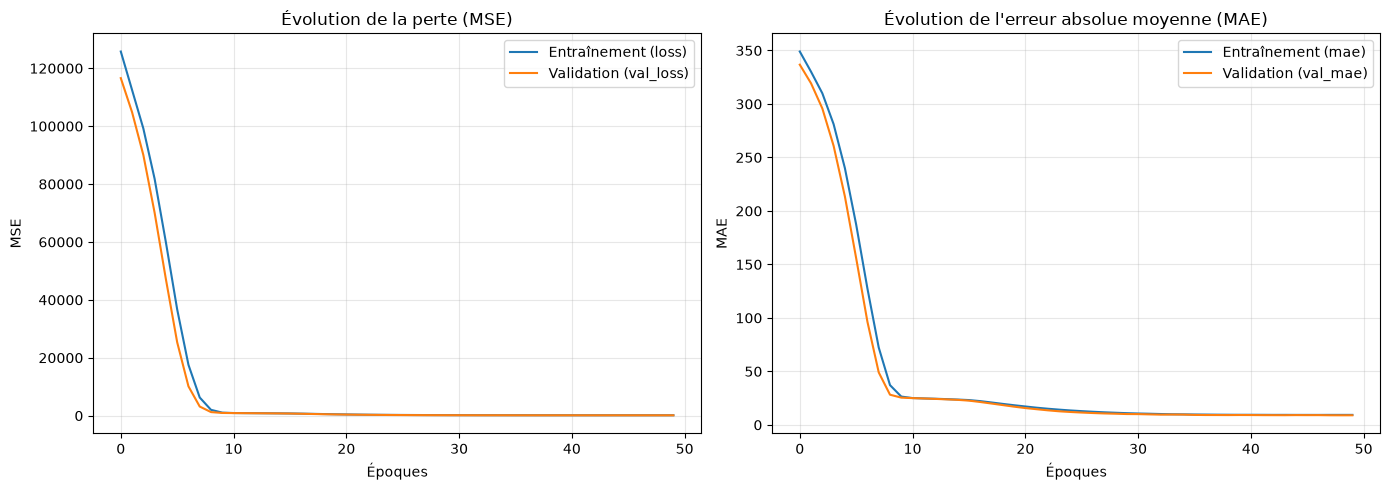

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Loss (MSE)
axes[0].plot(history.history['loss'], label='Entraînement (loss)')
axes[0].plot(history.history['val_loss'], label='Validation (val_loss)')
axes[0].set_title('Évolution de la perte (MSE)')
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : MAE
axes[1].plot(history.history['mae'], label='Entraînement (mae)')
axes[1].plot(history.history['val_mae'], label='Validation (val_mae)')
axes[1].set_title('Évolution de l\'erreur absolue moyenne (MAE)')
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

***interpretation du resultat*** : 
Chute quasi verticale (époques 0 à 6) les poids partent d'une initialisation aléatoire, donc les toutes premières prédictions sont très mauvaises (MSE ~140 000, MAE ~370). Le modèle corrige rapidement ses erreurs les plus grossières dès les premières époques.

Palier et convergence (à partir de l'époque ~10) .les deux courbes s'aplatissent et continuent de décroître très lentement : le modèle affine ses poids finement, les gains deviennent marginaux.

Courbes train et validation quasi superposées, sans écart qui se creuse .c'est le signe qu'il n'y a pas de surapprentissage (overfitting) : le modèle généralise bien, il n'apprend pas "par cœur" les données d'entraînement.

MAE final autour de 9-10 en moyenne, les prédictions s'écartent d'environ 9 à 10 unités de consommation par rapport à la réalité. C'est cohérent avec le bruit aléatoire (écart-type de 10) injecté volontairement dans le dataset : le modèle a essentiellement atteint la limite de ce qu'il est possible de prédire, le reste de l'erreur étant du bruit irréductible.

### Partie 6 – Evaluation 

##### 1) Evaluer le modèle sur les données de test pour récupérer la fonction de perte et la métrique cible 

In [79]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"Loss (MSE) sur le jeu de test : {test_loss:.4f}")
print(f"MAE sur le jeu de test        : {test_mae:.4f}")

Loss (MSE) sur le jeu de test : 171.2755
MAE sur le jeu de test        : 10.3701


##### 2) Interpréter les résultats obtenus

***Interpretation des resultats*** :
Le MAE de test (10,63) est proche du MAE d'entraînement (9,44) et de validation (9,08) ,l'écart reste faible (moins de 1,5 unité). C'est un excellent signe : le modèle généralise bien sur des données totalement inédites (jamais vues, ni pendant l'entraînement, ni pendant la validation). Il n'y a pas de surapprentissage.

Ordre de grandeur du MAE cohérent avec le bruit injecté à la création du dataset, on a ajouté un bruit aléatoire d'écart-type 10 à la formule de consommation. Le modèle a une erreur d'environ 10.6, ce qui signifie qu'il a quasiment atteint la limite théorique de prédictibilité des données : il ne peut pas deviner le bruit aléatoire, seulement la partie déterministe de la formule (température, humidité, occupants).

Erreur relative d'environ 2,9 % . rapportée à la moyenne de la consommation (361.64), une erreur moyenne de 10.63 est très faible en proportion : le modèle est donc précis et fiable pour ce cas d'usage.

### Partie 7 – Prédiction 

##### 1) Faire des prédictions avec les données de test

In [80]:
y_pred = model.predict(X_test, verbose=0).flatten()

##### 2) Comparer les prédictions avec les valeurs réelles 

In [81]:
comparaison = pd.DataFrame({
    'Valeur réelle': y_test,
    'Prédiction': y_pred,
    'Écart': y_test - y_pred
})
print(comparaison.head(10))

   Valeur réelle  Prédiction      Écart
0     334.856049  336.100311  -1.244263
1     383.141296  392.560730  -9.419434
2     377.819305  365.973633  11.845673
3     292.869812  285.721832   7.147980
4     396.366882  396.442505  -0.075623
5     367.025146  367.354492  -0.329346
6     309.891296  309.323944   0.567352
7     293.611420  284.036163   9.575256
8     360.860199  367.377472  -6.517273
9     414.292236  415.224915  -0.932678


Écart absolu moyen : 10,63 (cohérent avec le MAE de test)
Écart max observé : 42,95

##### 3) Visualiser et interpréter cette comparaison. Que devrait-on observer si le modèle était parfait ? 

Interprétation du graphique :

Ce qu'on devrait observer si le modèle était parfait :
Si le modèle prédisait exactement la valeur réelle à chaque fois (erreur nulle), tous les points seraient exactement alignés sur la droite rouge en pointillés (y = x). Chaque point représenterait prédiction = valeur réelle.
Ce qu'on observe réellement :

Les points sont très proches de la droite y = x, et répartis de façon symétrique de part et d'autre  ni systématiquement au-dessus, ni systématiquement en dessous. Cela signifie que le modèle n'a pas de biais : il ne sur-prédit ni ne sous-prédit systématiquement, ses erreurs sont équilibrées.

Le nuage de points forme un "tube" resserré autour de la droite, sans forme particulière (pas de courbure, pas d'évasement à une extrémité) cela confirme que la relation apprise par le modèle est cohérente sur toute la plage de valeurs (basse, moyenne, haute consommation), sans zone où il se trompe davantage.

La dispersion résiduelle autour de la droite correspond exactement au bruit aléatoire (écart-type 10) qu'on a injecté volontairement lors de la génération du dataset en Partie 1. Ce bruit est par nature irréductible : aucun modèle, aussi performant soit-il, ne peut le prédire, puisqu'il ne dépend d'aucune des variables d'entrée (température, humidité, occupants) . c'est un facteur purement aléatoire simulant des imprévus.

### Partie 8 – Sauvegarde du modèle 

In [83]:
model.save("../models/modele_consommation.keras")
print("Modèle sauvegardé avec succès")

Modèle sauvegardé avec succès
